#Business Question:
* Capped vs Uncapped Player Trends

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [3]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


##Average & Median Price
Business Question

- Do franchises pay significantly more for experienced (capped) players?

In [4]:
df.groupby("C/U")["Sold"].agg(
    Average_Price="mean",
    Median_Price="median",
    Player_Count="count"
).round(2)

,Average_Price,Median_Price,Player_Count
C/U,,,
Capped,7.97,6.5,132
Uncapped,1.37,0.4,95


Capped players commanded a significantly higher auction premium, with an average price of **₹7.97 Cr** compared to **₹1.37 Cr** for uncapped players. The median price also remained much higher (**₹6.5 Cr vs ₹0.4 Cr**), indicating that franchises consistently value experienced players rather than spending heavily on only a few marquee names.

##Price Distribution
Is spending concentrated on a few expensive players or spread evenly?

In [5]:
df.groupby("C/U")["Sold"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
C/U,,,,,,,,
Capped,132.0,7.97,6.53,0.3,2.0,6.5,12.06,27.0
Uncapped,95.0,1.37,1.55,0.3,0.3,0.4,1.90,6.0


The price range for capped players (**₹0.3–27 Cr**) was substantially wider than for uncapped players (**₹0.3–6 Cr**), with a much higher standard deviation (**₹6.53 Cr vs ₹1.55 Cr**). This suggests franchises are willing to make high-value investments in proven performers, while spending on uncapped players remains relatively controlled.

##Share of Total Spending

Business Question

* How much of the total auction budget went to capped vs uncapped players?

In [6]:
share = (
    df.groupby("C/U")["Sold"]
      .sum()
      .reset_index(name="Sold")
)

share["Spending Share %"] = (
    share["Sold"] /
    share["Sold"].sum() * 100
).round(2)

share

,C/U,Sold,Spending Share %
0,Capped,1052.1,89.0
1,Uncapped,130.0,11.0


Franchises allocated **89% of the total auction budget (₹1,052.1 Cr)** to capped players, while uncapped players received only **11% (₹130 Cr)**. This highlights that auction budgets are primarily directed toward experienced talent expected to deliver immediate performance.

##Team Preferences
Business Question

* Which teams rely more on capped players and which teams actively invest in uncapped talent?

In [8]:
team_pref = pd.crosstab(
    df["Team"],
    df["C/U"],
    margins=False
)

team_pref.columns = ["Capped", "Uncapped"]

team_pref["% Capped"] = (
    team_pref["Capped"] /
    (team_pref["Capped"] + team_pref["Uncapped"]) * 100
).round(1)

team_pref["% Uncapped"] = (
    team_pref["Uncapped"] /
    (team_pref["Capped"] + team_pref["Uncapped"]) * 100
).round(1)

team_pref.sort_values("% Capped", ascending=False)

,Capped,Uncapped,% Capped,% Uncapped
Team,,,,
KKR,15,6,71.4,28.6
SRH,13,7,65.0,35.0
RCB,14,8,63.6,36.4
MI,14,9,60.9,39.1
RR,12,8,60.0,40.0
CSK,15,10,60.0,40.0
GT,14,11,56.0,44.0
DC,12,11,52.2,47.8
PBKS,12,13,48.0,52.0


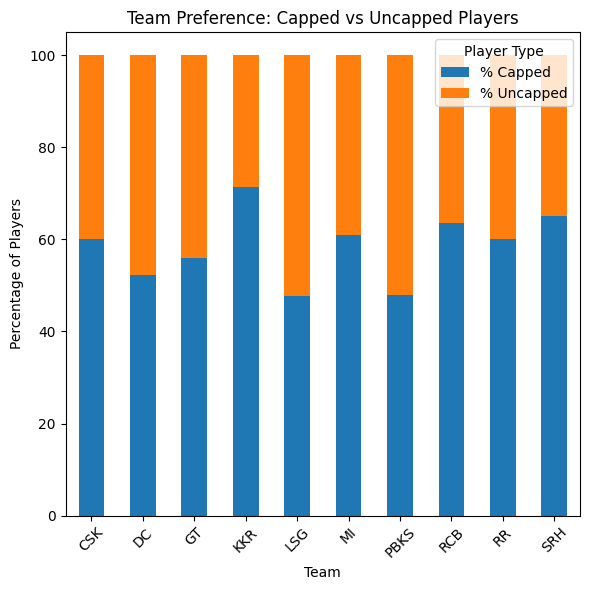

In [9]:
import matplotlib.pyplot as plt

team_pref[["% Capped", "% Uncapped"]].plot(
    kind="bar",
    stacked=True,
    figsize=(6,6)
)

plt.title("Team Preference: Capped vs Uncapped Players")
plt.xlabel("Team")
plt.ylabel("Percentage of Players")
plt.xticks(rotation=45)
plt.legend(title="Player Type")
plt.tight_layout()

plt.show()

Recruitment strategies varied across franchises. **LSG (47.8% capped; 52.2% uncapped)** and **PBKS (48.0% capped; 52.0% uncapped)** maintained relatively balanced squads with a slight preference for **uncapped** players. In contrast, **KKR (71.4% capped)**, **SRH (65.0% capped)**, and **RCB (63.6% capped)** allocated a substantially higher proportion of their squads to **capped** players, reflecting a greater emphasis on experienced talent while complementing their rosters with a smaller share of emerging uncapped players.


##Investment Pattern

Business Question

* Are teams spending significantly more on capped players than uncapped players?

In [10]:
investment = (
    df.groupby(["Team", "C/U"])["Sold"]
      .sum()
      .unstack()
      .fillna(0)
)

investment.columns = ["Capped Spend", "Uncapped Spend"]

investment["Total Spend"] = (
    investment["Uncapped Spend"] +
    investment["Capped Spend"]
)

investment["% Spend on Capped"] = (
    investment["Capped Spend"] /
    investment["Total Spend"] * 100
).round(1)

investment.sort_values("% Spend on Capped", ascending=False)

,Capped Spend,Uncapped Spend,Total Spend,% Spend on Capped
Team,,,,
SRH,112.60,7.20,119.80,94.0
MI,111.60,8.20,119.80,93.2
RR,111.35,8.35,119.70,93.0
CSK,110.80,9.15,119.95,92.4
KKR,98.15,9.80,107.95,90.9
DC,103.00,13.55,116.55,88.4
RCB,103.95,15.30,119.25,87.2
GT,103.70,16.15,119.85,86.5
LSG,102.15,17.45,119.60,85.4


Although several teams recruited a relatively higher proportion of capped players, the majority of auction budgets remained concentrated on capped players across all franchises. **SRH (₹112.60 Cr)**, **MI (₹111.60 Cr)**, and **RR (₹111.35 Cr)** recorded the highest expenditure on capped players, allocating **94.0%**, **93.2%**, and **93.0%** of their total budgets, respectively. In contrast, **PBKS (₹94.80 Cr)**, **KKR (₹98.15 Cr)**, and **LSG (₹102.15 Cr)** spent comparatively less on capped players.


# Overall Business Insight

The auction data shows that IPL franchises prioritize quality over quantity when investing in experienced players. Despite uncapped players representing a substantial portion of squad selections, 89% of the total auction spending (₹1,052.1 Cr) was directed toward capped players, who achieved an average price of ₹7.97 Cr, nearly six times higher than uncapped players (₹1.37 Cr). While teams such as **LSG and PBKS maintained a more balanced recruitment strategy** (with uncapped players making up over 52% of their squads), others like **KKR and SRH leaned most heavily on capped talent**, with KKR fielding 71.4% capped players and SRH directing 94% of its total spend toward capped players — the highest share among all franchises. Overall, franchises appear to use capped players for immediate competitive impact and uncapped players to strengthen long-term squad depth within budget constraints.